# Problem Statement: Analysis of Student Dropout Determinants in Kenyan Higher Education

## 1. Background & Context
Student dropout from higher education institutions is a critical challenge in Kenya, leading to significant individual, social, and economic costs. These include wasted educational resources, reduced skilled workforce, increased unemployment, and lower lifetime earnings for the individuals who drop out. Understanding the multifaceted factors that contribute to this phenomenon is essential for developing effective, data-driven retention strategies. This dataset captures information on 118,000+ students, providing a rich opportunity to explore the complex interplay of academic, financial, demographic, and engagement-related factors.

## 2. Problem Identification
The core problem is the unexplained and unmitigated student dropout phenomenon in the Kenyan higher education context. Specifically, we investigate:
- What is the primary driver of dropout: academic preparedness, current performance, or financial constraints?
- How do financial factors interact with academic factors to influence dropout risk?
- Does the impact vary significantly by demographics, programme of study, or engagement levels?
- Can a predictive model identify students at high risk of dropping out early?

## 3. Objectives
1. **Descriptive Analysis** — Profile the student population and compare characteristics of dropouts vs. persisters.
2. **Exploratory Analysis** — Investigate relationships between independent variables and dropout status.
3. **Predictive Modelling** — Develop and evaluate a stacking classifier to predict dropout risk.
4. **Actionable Insights** — Translate findings into recommendations for administrators and policymakers.

## 1. Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Statistics
from scipy.stats import chi2_contingency, ttest_ind

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

# Model selection & tuning
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score, recall_score,
    roc_curve, auc, precision_recall_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')


## 2. Data Loading

In [2]:
School_df = pd.read_csv("student.csv")
School_df.head()

,Gender,Birthdate,PHYSICALLYCHALLENGED,County,Loan_serial_number,ScholarshipApplied,InstitutionCode,InstitutionName,COURSECODE,ProgramCost,...,Category,applicanttype,LoanStatus,Unnamed: 21,Mother_Age,Father_Age,Father_educ_level,Mother_educ_level,Highest_educ_level,Drop_out
0,Male,13/03/1996,0,MIGORI,2510374563,0,KPU,TECHNICAL UNIVERSITY OF KENYA,EEEI,270000.0,...,PublicUniversityGovtSponsored,1,Partially Disbursed,NaN,69,64,Primary,Primary,Primary,0
1,Male,08/07/1982,0,NaN,2510057518,0,CA,Catholic University,BED,160000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,63,65,Diploma,Secondary,Diploma,1
2,Male,18/02/1993,0,NaN,2510233585,0,MTK,Mount Kenya University,BBIT,111000.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,54,57,Primary,Secondary,Secondary,0
3,Male,18/03/1986,0,NaN,2510031694,0,KAFUCO,Kaimosi Friends University,HNR,275400.0,...,PublicUniversitySelfSponsored,1,Allocated,NaN,51,76,Diploma,Primary,Diploma,0
4,Male,31/10/1987,0,NAKURU,2510438107,0,UBG,Bugema University,BHT,0.0,...,PrivateUniversitySelfSponsored,1,Partially Disbursed,NaN,58,64,Secondary,Secondary,Secondary,0


In [3]:
print(School_df.shape)
School_df.info()

(118259, 28)
<class 'pandas.DataFrame'>
RangeIndex: 118259 entries, 0 to 118258
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                62659 non-null   str    
 1   Birthdate             118259 non-null  str    
 2   PHYSICALLYCHALLENGED  118259 non-null  int64  
 3   County                118235 non-null  str    
 4   Loan_serial_number    118259 non-null  int64  
 5   ScholarshipApplied    118259 non-null  int64  
 6   InstitutionCode       118259 non-null  str    
 7   InstitutionName       118259 non-null  str    
 8   COURSECODE            117794 non-null  str    
 9   ProgramCost           117794 non-null  float64
 10  CourseCategory        114059 non-null  str    
 11  Adm No                118233 non-null  str    
 12  ExamYear              118259 non-null  int64  
 13  INDEXNUMBER           118258 non-null  object 
 14  TotalLoanAllocated    118259 non-null  float64
 15

In [4]:
School_df.isna().sum()

Gender                   55600
Birthdate                    0
PHYSICALLYCHALLENGED         0
County                      24
Loan_serial_number           0
ScholarshipApplied           0
InstitutionCode              0
InstitutionName              0
COURSECODE                 465
ProgramCost                465
CourseCategory            4200
Adm No                      26
ExamYear                     0
INDEXNUMBER                  1
TotalLoanAllocated           0
LoanproductCode              0
BursaryAllocated             0
BURSARYBATCHNUMBER      118259
Category                     0
applicanttype                0
LoanStatus                   3
Unnamed: 21             118259
Mother_Age                   0
Father_Age                   0
Father_educ_level        16817
Mother_educ_level        20568
Highest_educ_level       13548
Drop_out                     0
dtype: int64

## 3. Data Cleaning

### 3.1 Drop Irrelevant Columns

In [5]:
columns_to_drop = [
    'BURSARYBATCHNUMBER', 'Unnamed: 21', 'PHYSICALLYCHALLENGED',
    'Loan_serial_number', 'InstitutionCode', 'Adm No',
    'COURSECODE', 'INDEXNUMBER', 'BursaryAllocated', 'applicanttype'
]
School_df = School_df.drop(columns=columns_to_drop, errors='ignore')
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out'],
      dtype='str')

### 3.2 Drop Rows with Missing Values in Key Columns

In [6]:
School_df = School_df.dropna(subset=[
    "Gender", "County", "ProgramCost", "CourseCategory",
    "Father_educ_level", "Mother_educ_level", "LoanStatus", "Highest_educ_level"
])
School_df.isna().sum()

Gender                0
Birthdate             0
County                0
ScholarshipApplied    0
InstitutionName       0
ProgramCost           0
CourseCategory        0
ExamYear              0
TotalLoanAllocated    0
LoanproductCode       0
Category              0
LoanStatus            0
Mother_Age            0
Father_Age            0
Father_educ_level     0
Mother_educ_level     0
Highest_educ_level    0
Drop_out              0
dtype: int64

### 3.3 Remove Unsupported Loan Product Codes

In [7]:
School_df = School_df[
    ~School_df['LoanproductCode'].isin(['DL6', 'VC'])
]
School_df['LoanproductCode'].value_counts()

LoanproductCode
UG    47652
Name: count, dtype: int64

### 3.4 Remove Duplicates

In [8]:
print("Duplicates before:", School_df.duplicated().sum())
School_df = School_df.drop_duplicates()
print("Duplicates after:", School_df.duplicated().sum())

Duplicates before: 6
Duplicates after: 0


## 4. Feature Engineering

### Assumptions
- Age 16+ is eligible to join an undergraduate programme.

### 4.1 Create Age Column

In [9]:
# Convert Birthdate to datetime and derive age
School_df["Birthdate"] = pd.to_datetime(School_df["Birthdate"], errors="coerce")
today = datetime.today()
School_df["age"] = School_df["Birthdate"].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
    if pd.notnull(x) else None
)

### 4.2 Extract University Type and Sponsorship from Category

In [10]:
School_df[['UniversityType', 'Sponsored']] = School_df['Category'].str.extract(
    r'^(Public|Private).*?(GovtSponsored|SelfSponsored)$'
)
School_df[['UniversityType', 'Sponsored']].value_counts()

UniversityType  Sponsored    
Public          GovtSponsored    41972
Private         SelfSponsored     3699
Public          SelfSponsored     1132
Private         GovtSponsored      843
Name: count, dtype: int64

### 4.3 Create Age Groups

In [11]:
bins   = [0, 18, 21, 25]
labels = ['<17', '18-21', '22-25']
School_df['age_group'] = pd.cut(School_df['age'], bins=bins, labels=labels)
School_df['age_group'].value_counts()

age_group
18-21    35738
<17       5935
22-25     5324
Name: count, dtype: int64

### 4.4 Export Cleaned Dataset

In [12]:
School_df.to_csv('cleaned.csv', index=False)
print(f"Cleaned dataset saved: {School_df.shape[0]} rows, {School_df.shape[1]} columns")

Cleaned dataset saved: 47646 rows, 22 columns


## 5. Exploratory Data Analysis

### 5.1 Age Distribution

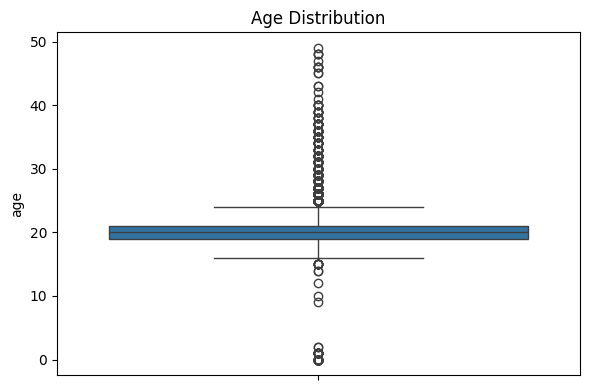

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=School_df['age'])
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

In [14]:
# Filter to valid student age range to deal with
School_df = School_df[School_df['age'] >= 17]
School_df = School_df[(School_df['age'] >= 16) & (School_df['age'] <= 25)]
School_df['age'].describe()

count    46883.000000
mean        19.801868
std          1.372580
min         17.000000
25%         19.000000
50%         20.000000
75%         20.000000
max         25.000000
Name: age, dtype: float64

In [15]:
School_df.age.value_counts()

age
19.0    17204
20.0    12156
21.0     6378
18.0     5148
22.0     3178
23.0     1339
17.0      673
24.0      556
25.0      251
Name: count, dtype: int64

### 5.2 School Drop Out Rate by County in Kenya

In [16]:
# 1. Standardize to uppercase and strip whitespace
School_df['County'] = School_df['County'].astype(str).str.upper().str.strip()

# 2. Cleanup punctuation and spacing
# We replace slashes and hyphens with spaces, but we'll handle the apostrophe carefully
School_df['County'] = School_df['County'].str.replace(r'[-/]', ' ', regex=True)
School_df['County'] = School_df['County'].str.replace(r'\s+', ' ', regex=True)

# 3. Specific fix for Murang'a and other duplicates
mapping = {
    'MURANG A': "MURANG'A",
    'MURANGA': "MURANG'A",
    'TRANSNZOIA': 'TRANS NZOIA'
}

School_df['County'] = School_df['County'].replace(mapping)

# 4. Verification
unique_counties = sorted(School_df['County'].unique())
print(f"Unique County Count: {len(unique_counties)}")
print(unique_counties)

Unique County Count: 47
['BARINGO', 'BOMET', 'BUNGOMA', 'BUSIA', 'ELGEYO MARAKWET', 'EMBU', 'GARISSA', 'HOMA BAY', 'ISIOLO', 'KAJIADO', 'KAKAMEGA', 'KERICHO', 'KIAMBU', 'KILIFI', 'KIRINYAGA', 'KISII', 'KISUMU', 'KITUI', 'KWALE', 'LAIKIPIA', 'LAMU', 'MACHAKOS', 'MAKUENI', 'MANDERA', 'MARSABIT', 'MERU', 'MIGORI', 'MOMBASA', "MURANG'A", 'NAIROBI', 'NAKURU', 'NANDI', 'NAROK', 'NYAMIRA', 'NYANDARUA', 'NYERI', 'SAMBURU', 'SIAYA', 'TAITA TAVETA', 'TANA RIVER', 'THARAKA NITHI', 'TRANS NZOIA', 'TURKANA', 'UASIN GISHU', 'VIHIGA', 'WAJIR', 'WEST POKOT']


In [17]:
School_df.County.unique()

<StringArray>
[       'KAKAMEGA',         'KAJIADO',         'NAIROBI',          'KIAMBU',
           'KITUI',        'MACHAKOS',     'UASIN GISHU',         'MOMBASA',
          'MIGORI', 'ELGEYO MARAKWET',         'BUNGOMA',         'NYAMIRA',
          'KILIFI',           'BOMET',     'TRANS NZOIA',          'KISUMU',
        'HOMA BAY',            'MERU',   'THARAKA NITHI',           'KWALE',
        'MURANG'A',           'NYERI',           'BUSIA',          'NAKURU',
           'KISII',       'KIRINYAGA',           'NANDI',          'VIHIGA',
           'SIAYA',         'MAKUENI',       'NYANDARUA',    'TAITA TAVETA',
        'LAIKIPIA',         'KERICHO',            'LAMU',           'NAROK',
         'SAMBURU',         'BARINGO',            'EMBU',      'WEST POKOT',
         'GARISSA',        'MARSABIT',         'TURKANA',      'TANA RIVER',
          'ISIOLO',         'MANDERA',           'WAJIR']
Length: 47, dtype: str

In [18]:
# Create the summary table
dropout_table = School_df.groupby('County').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_table['Dropout_Percentage'] = (
    dropout_table['Dropout_Count'] / dropout_table['Total_Students'] * 100
).round(2)

# Sort by highest dropout percentage
dropout_table = dropout_table.sort_values('Dropout_Percentage', ascending=False)

# Reset index cleanly
dropout_table = dropout_table.reset_index(drop=True)

print(dropout_table)

             County  Total_Students  Dropout_Count  Dropout_Percentage
0           MANDERA              21              9               42.86
1             WAJIR              28             11               39.29
2          MARSABIT              90             34               37.78
3              LAMU              60             22               36.67
4           SAMBURU              73             25               34.25
5         KIRINYAGA             373            125               33.51
6              EMBU             447            149               33.33
7            KISUMU            1858            594               31.97
8       TRANS NZOIA            1236            395               31.96
9           NYAMIRA            1725            546               31.65
10            BOMET            1387            436               31.43
11          BUNGOMA            2080            644               30.96
12            BUSIA            1295            400               30.89
13    

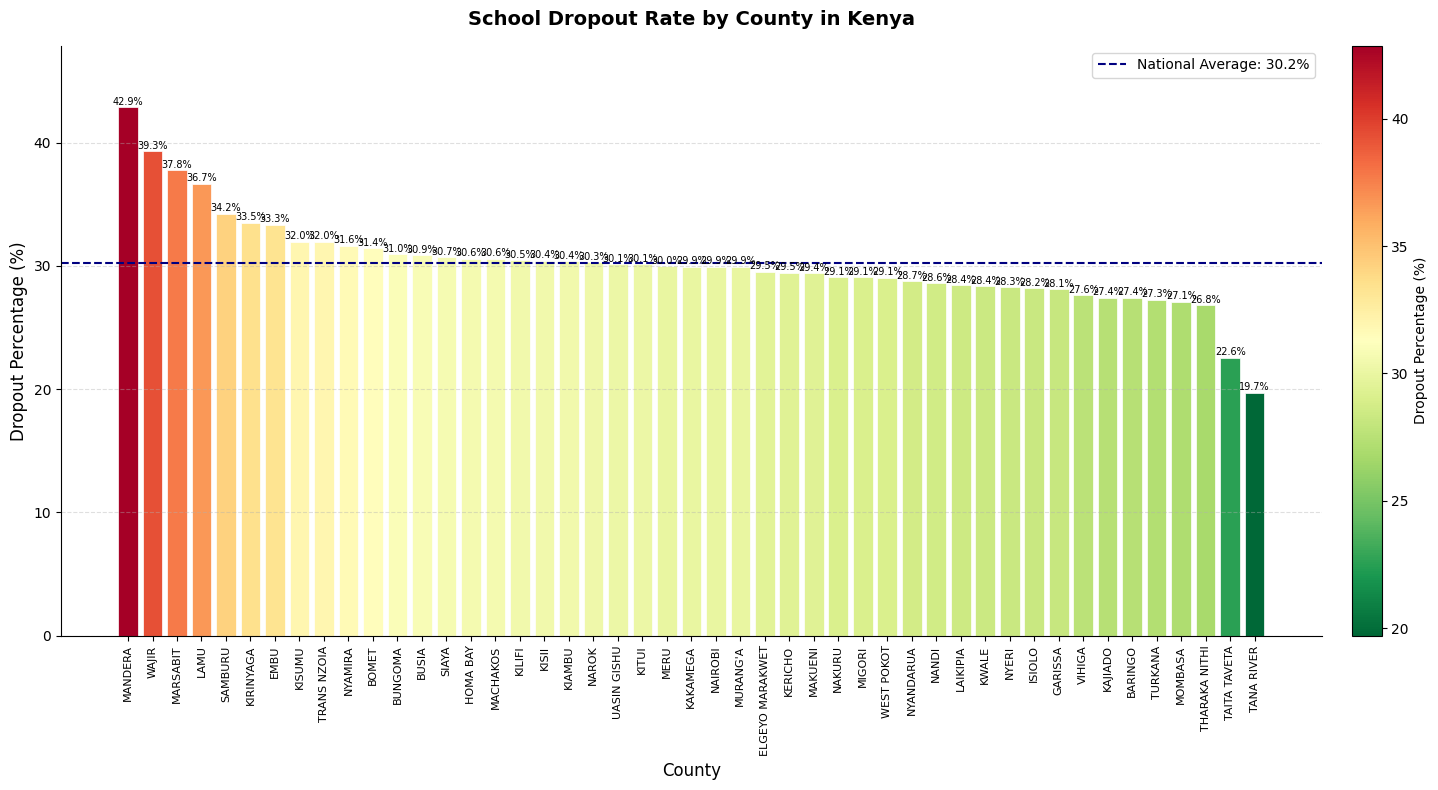

In [19]:
# Sort by percentage highest to lowest
dropout_plot = dropout_table.sort_values('Dropout_Percentage', ascending=False).reset_index(drop=True)

# Create colour gradient — green (low) to red (high)
norm = plt.Normalize(
    dropout_plot['Dropout_Percentage'].min(),
    dropout_plot['Dropout_Percentage'].max()
)
colors = cm.RdYlGn_r(norm(dropout_plot['Dropout_Percentage']))

# Create the figure
fig, ax = plt.subplots(figsize=(16, 8))

# Plot vertical bar chart with gradient colours
bars = ax.bar(
    dropout_plot['County'],
    dropout_plot['Dropout_Percentage'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add percentage labels on top of each bar
for bar, val in zip(bars, dropout_plot['Dropout_Percentage']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center',
        fontsize=7
    )

# Add colourbar legend
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Dropout Percentage (%)', fontsize=10)

# Formatting
ax.set_ylabel('Dropout Percentage (%)', fontsize=12)
ax.set_xlabel('County', fontsize=12)
ax.set_title('School Dropout Rate by County in Kenya', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, dropout_plot['Dropout_Percentage'].max() + 5)
ax.axhline(
    dropout_table['Dropout_Percentage'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f"National Average: {dropout_table['Dropout_Percentage'].mean():.1f}%"
)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
#Create the summary table by ExamYear
dropout_year_table = School_df.groupby('ExamYear').agg(
    Total_Students = ('Drop_out', 'count'),
    Dropout_Count  = ('Drop_out', 'sum')
).reset_index()

# Calculate dropout percentage
dropout_year_table['Dropout_Percentage'] = (
    dropout_year_table['Dropout_Count'] / dropout_year_table['Total_Students'] * 100
).round(2)

# Sort by ExamYear
dropout_year_table = dropout_year_table.sort_values('ExamYear', ascending=True).reset_index(drop=True)

print(dropout_year_table)

   ExamYear  Total_Students  Dropout_Count  Dropout_Percentage
0      2016               1              0                0.00
1      2017              18              8               44.44
2      2018              50             14               28.00
3      2019             146             38               26.03
4      2020             362            117               32.32
5      2021            1098            320               29.14
6      2022             680            198               29.12
7      2023            2273            662               29.12
8      2024           42255          12745               30.16


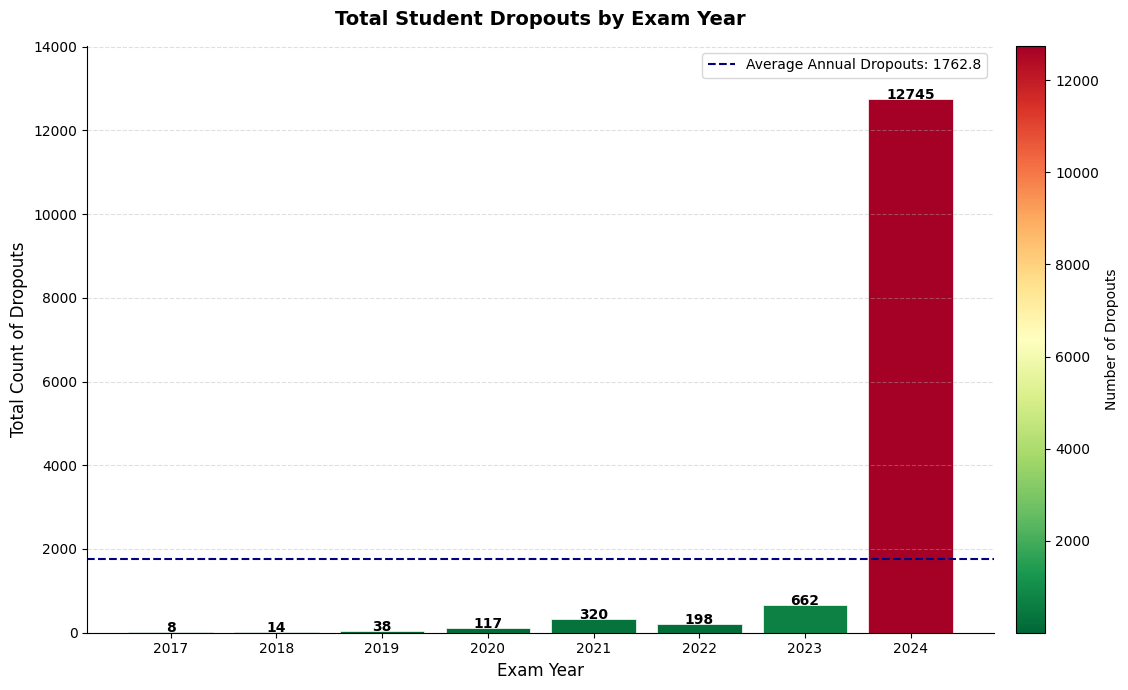

In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Prepare the data: Count the number of dropouts per year
# We filter the dataframe for only dropouts and then group by year
dropout_counts = School_df[School_df['Drop_out'] == 1].groupby('ExamYear').size().reset_index(name='Dropout_Count')

# 2. Plotting logic
fig, ax = plt.subplots(figsize=(12, 7))

# Normalization for the color map based on counts
norm = plt.Normalize(
    dropout_counts['Dropout_Count'].min(),
    dropout_counts['Dropout_Count'].max()
)
colors = cm.RdYlGn_r(norm(dropout_counts['Dropout_Count']))

bars = ax.bar(
    dropout_counts['ExamYear'].astype(str),
    dropout_counts['Dropout_Count'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add count labels on top of each bar
for bar, val in zip(bars, dropout_counts['Dropout_Count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{int(val)}',  # Displaying as integer count
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Colourbar updated for counts
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Number of Dropouts', fontsize=10)

# Labels and Title
ax.set_ylabel('Total Count of Dropouts', fontsize=12)
ax.set_xlabel('Exam Year', fontsize=12)
ax.set_title('Total Student Dropouts by Exam Year', fontsize=14, fontweight='bold', pad=15)

# Update Y-limit to provide space for labels
ax.set_ylim(0, dropout_counts['Dropout_Count'].max() * 1.1)

# Horizontal line for the average annual count
avg_count = dropout_counts['Dropout_Count'].mean()
ax.axhline(
    avg_count,
    color='navy', linestyle='--', linewidth=1.5,
    label=f"Average Annual Dropouts: {avg_count:.1f}"
)

ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
School_df.shape

(46883, 22)

In [23]:
# 1. (Optional but recommended) Ensure ExamYear is numeric to avoid type errors
School_df['ExamYear'] = pd.to_numeric(School_df['ExamYear'], errors='coerce')

# 2. Filter for the year 2024
School_df = School_df[School_df['ExamYear'] == 2024]

# 3. Check the results
print(f"Rows after filtering: {len(School_df)}")
print(f"Unique years in data: {School_df['ExamYear'].unique()}")

Rows after filtering: 42255
Unique years in data: [2024]


### 5.3 Age Group vs Dropout

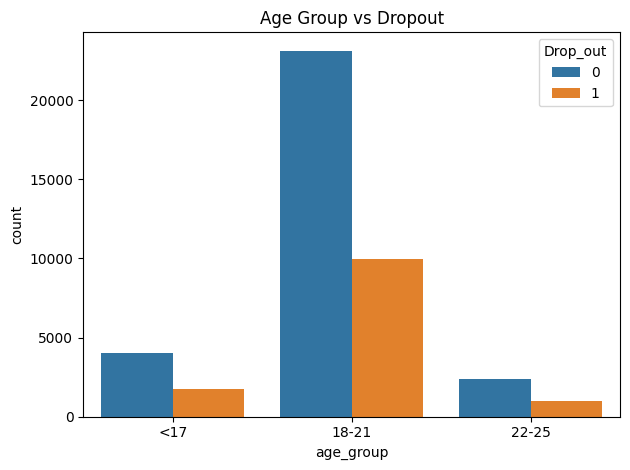

In [24]:
sns.countplot(x='age_group', hue='Drop_out', data=School_df)
plt.title('Age Group vs Dropout')
plt.tight_layout()
plt.show()

### 5.4 Loan-to-Cost Ratio by University Type

# Remove Outliers

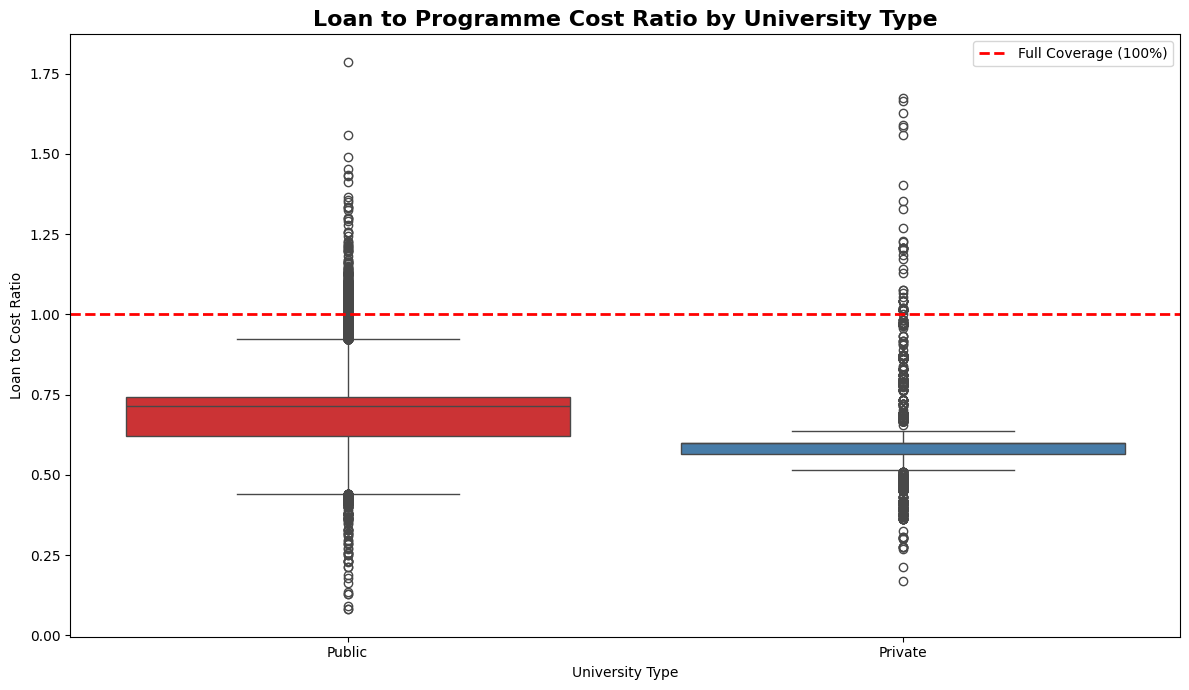

In [25]:
df_ratio = School_df.dropna(subset=['ProgramCost', 'TotalLoanAllocated']).copy()
df_ratio = df_ratio[df_ratio['ProgramCost'] > 0]
df_ratio['LoanToCostRatio'] = (df_ratio['TotalLoanAllocated'] / df_ratio['ProgramCost']).clip(upper=2)

plt.figure(figsize=(12, 7))
sns.boxplot(x='UniversityType', y='LoanToCostRatio', data=df_ratio, palette='Set1')
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Full Coverage (100%)')
plt.title('Loan to Programme Cost Ratio by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Loan to Cost Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
School_df.columns

Index(['Gender', 'Birthdate', 'County', 'ScholarshipApplied',
       'InstitutionName', 'ProgramCost', 'CourseCategory', 'ExamYear',
       'TotalLoanAllocated', 'LoanproductCode', 'Category', 'LoanStatus',
       'Mother_Age', 'Father_Age', 'Father_educ_level', 'Mother_educ_level',
       'Highest_educ_level', 'Drop_out', 'age', 'UniversityType', 'Sponsored',
       'age_group'],
      dtype='str')

**Interpretation:** Public universities show a higher loan-to-cost ratio due to government support and lower fees.
Private universities have a lower ratio, reflecting higher programme costs relative to loan allocations.

### 5.6 Dropout Rate by Age Group

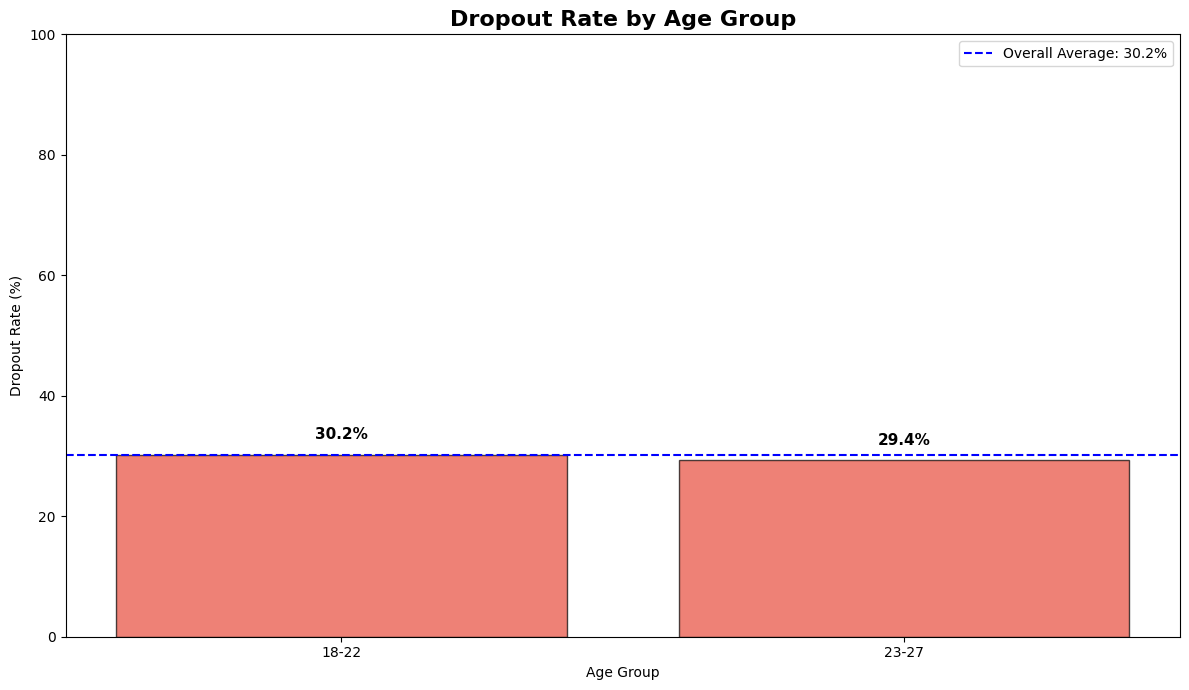

In [27]:
df_age_group = School_df.dropna(subset=['age']).copy()
df_age_group = df_age_group[(df_age_group['age'] >= 18) & (df_age_group['age'] <= 60)]
bins2   = [18, 22, 27, 32, 40, 100]
labels2 = ['18-22', '23-27', '28-32', '33-40', '40+']
df_age_group['AgeGroup'] = pd.cut(df_age_group['age'], bins=bins2, labels=labels2, right=False)
dropout_by_age = df_age_group.groupby('AgeGroup')['Drop_out'].agg(['mean', 'count'])
dropout_by_age = dropout_by_age[dropout_by_age['count'] > 10]

plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(dropout_by_age)), dropout_by_age['mean'] * 100,
               color='#e74c3c', edgecolor='black', alpha=0.7)
plt.xticks(range(len(dropout_by_age)), dropout_by_age.index)
plt.title('Dropout Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 100)
for bar, rate in zip(bars, dropout_by_age['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{rate*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
overall = df_age_group['Drop_out'].mean() * 100
plt.axhline(y=overall, color='blue', linestyle='--', label=f'Overall Average: {overall:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

### 5.7 Scholarship Application & Loan Amount

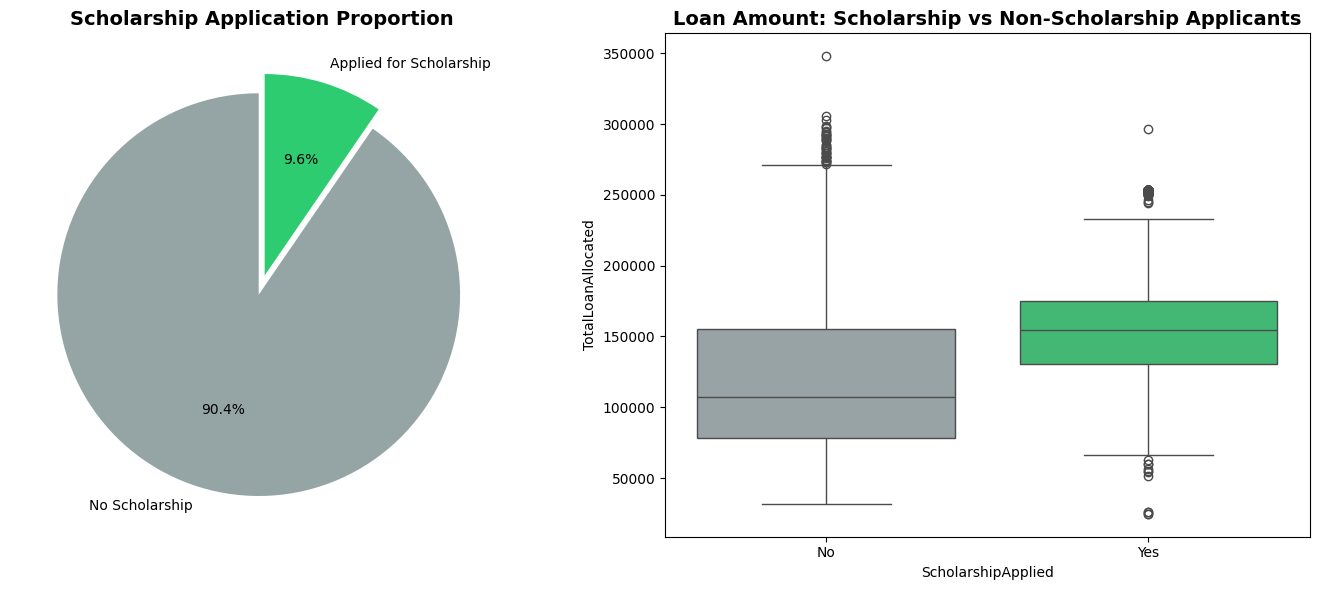

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scholarship_counts = School_df['ScholarshipApplied'].value_counts()
axes[0].pie(scholarship_counts.values,
            labels=['No Scholarship', 'Applied for Scholarship'],
            autopct='%1.1f%%', colors=['#95a5a6', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Scholarship Application Proportion', fontsize=14, fontweight='bold')

sns.boxplot(x='ScholarshipApplied', y='TotalLoanAllocated', data=School_df,
            ax=axes[1], palette=['#95a5a6', '#2ecc71'])
axes[1].set_title('Loan Amount: Scholarship vs Non-Scholarship Applicants', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

### 5.8 Loan Distribution by Demographic Groups

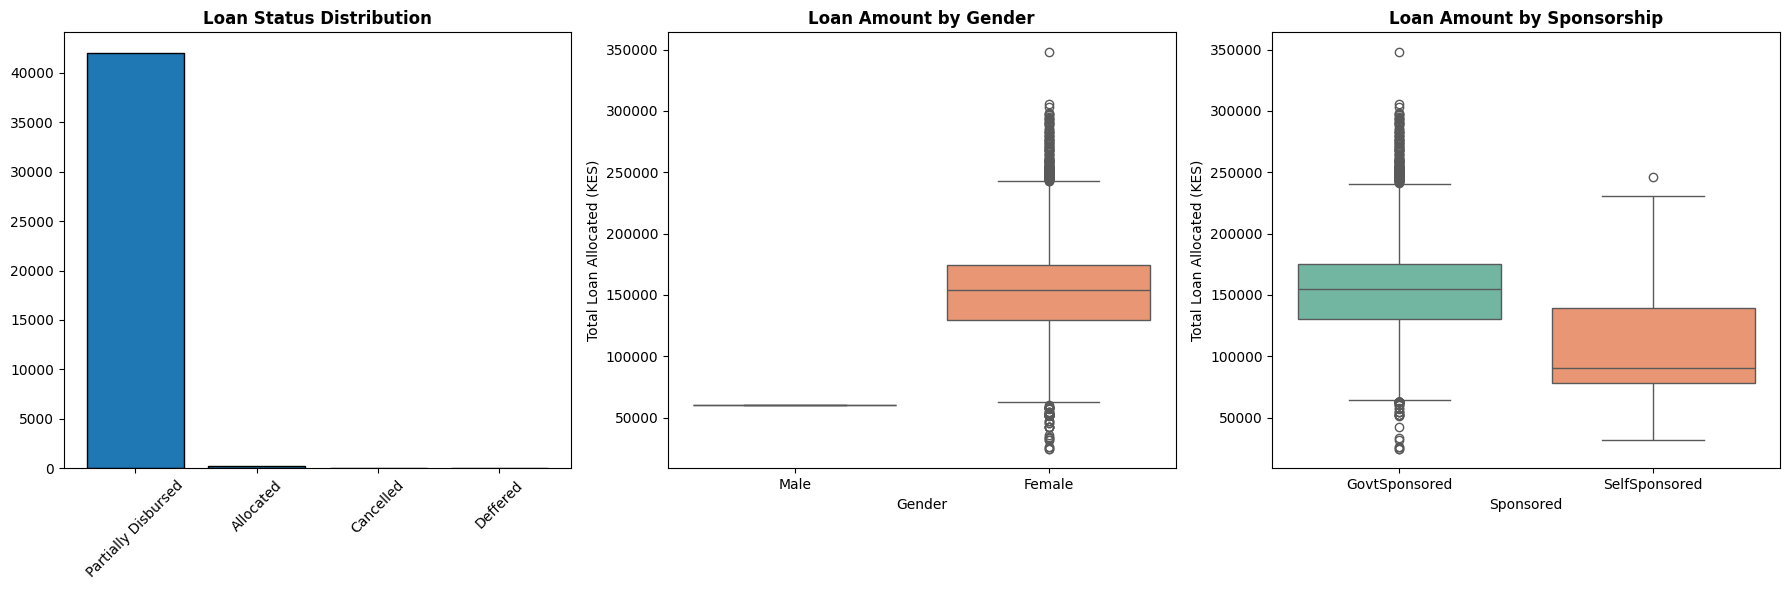

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes,
                           ['LoanStatus', 'Gender', 'Sponsored'],
                           ['Loan Status Distribution', 'Loan Amount by Gender', 'Loan Amount by Sponsorship']):
    if col == 'LoanStatus':
        counts = School_df[col].value_counts()
        ax.bar(counts.index, counts.values, edgecolor='black')
        ax.set_title(title, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
    else:
        sns.boxplot(x=col, y='TotalLoanAllocated', data=School_df, ax=ax, palette='Set2')
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Total Loan Allocated (KES)')

plt.tight_layout()
plt.show()

### 5.11 Dropout Status by University Type

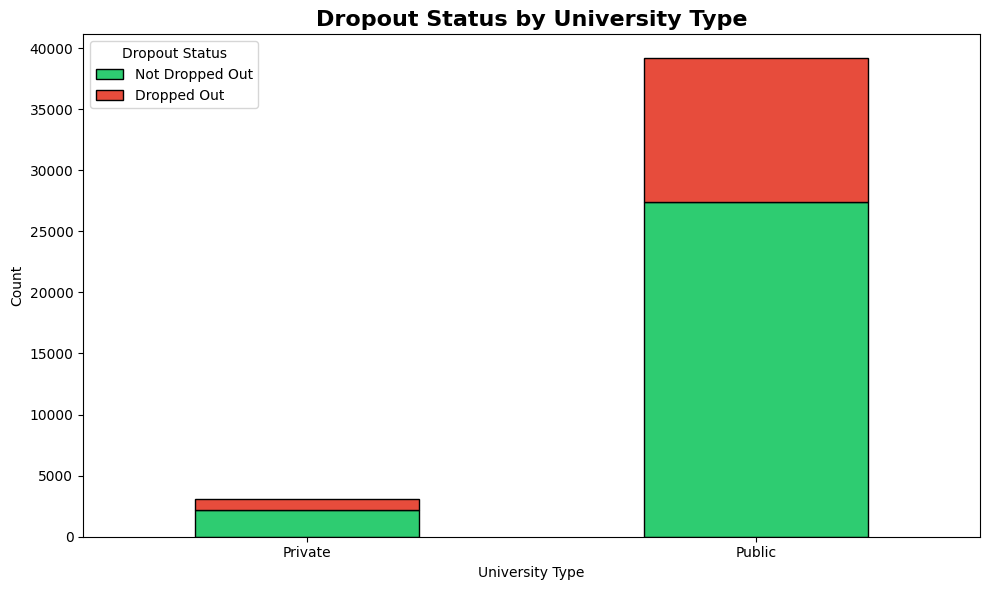

In [30]:
dropout_by_type = pd.crosstab(School_df['UniversityType'], School_df['Drop_out'])
dropout_by_type.columns = ['Not Dropped Out', 'Dropped Out']
dropout_by_type.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black', figsize=(10, 6))
plt.title('Dropout Status by University Type', fontsize=16, fontweight='bold')
plt.xlabel('University Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Dropout Status')
plt.tight_layout()
plt.show()

In [31]:
# Filter the dataframe to exclude 'Private'
School_df = School_df[School_df['UniversityType'] != 'Private']

# Optional: Reset the index after dropping rows
School_df = School_df.reset_index(drop=True)

# Verification
print(f"Remaining rows: {len(School_df)}")
print(f"University types currently in data: {School_df['UniversityType'].unique()}")

Remaining rows: 39166
University types currently in data: <StringArray>
['Public']
Length: 1, dtype: str


### 5.12 Average Loan by Parental Education Level

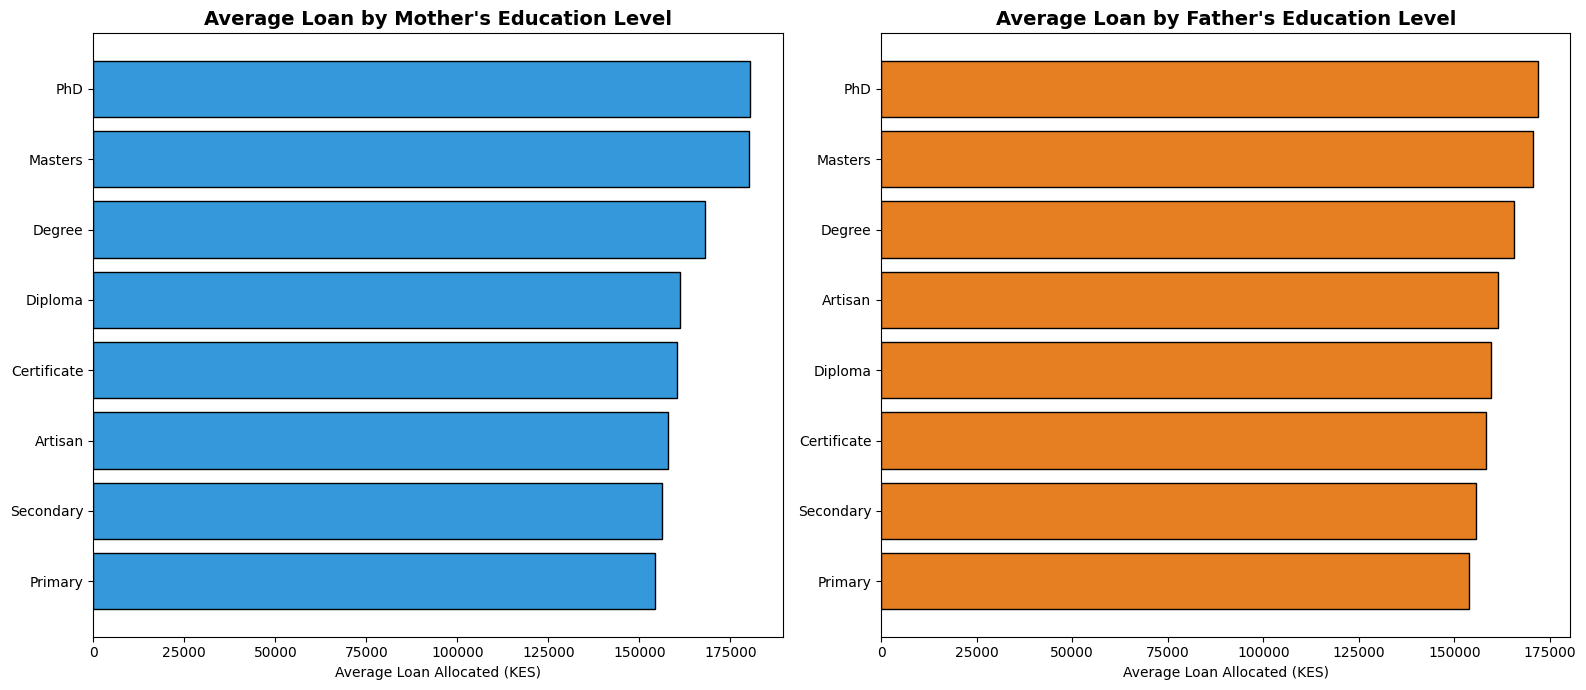

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, color, title in zip(
    axes,
    ['Mother_educ_level', 'Father_educ_level'],
    ['#3498db', '#e67e22'],
    ["Average Loan by Mother's Education Level", "Average Loan by Father's Education Level"]
):
    edu = School_df.groupby(col)['TotalLoanAllocated'].mean().sort_values()
    ax.barh(edu.index, edu.values, color=color, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Loan Allocated (KES)')
plt.tight_layout()
plt.show()

## 6. Hypothesis Tests

### 6.1 Scholarship Application vs Dropout
- **H₀:** No significant association between scholarship application and dropout status.
- **H₁:** Scholarship application is significantly associated with dropout status.

In [33]:
table = pd.crosstab(School_df['ScholarshipApplied'], School_df['Drop_out'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print("Decision:", "Reject H₀" if p < 0.05 else "Fail to reject H₀")

Chi-square statistic: 0.0525
p-value: 0.8188
Decision: Fail to reject H₀


### 6.2 Loan Amount vs Dropout
- **H₀:** Loan amount has no effect on dropout status.
- **H₁:** Loan amount is significantly associated with dropout status.

T-statistic: -1.4771
P-value: 0.1397
Decision: Fail to reject H₀


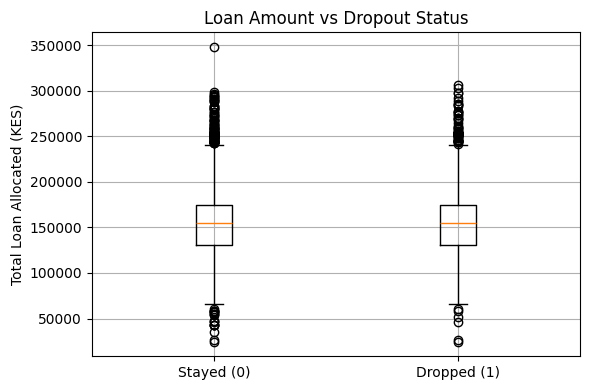

In [34]:
dropped = School_df[School_df['Drop_out'] == 1]['TotalLoanAllocated'].dropna()
stayed  = School_df[School_df['Drop_out'] == 0]['TotalLoanAllocated'].dropna()
t_stat, p_value = ttest_ind(dropped, stayed, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print("Decision:", "Reject H₀" if p_value < 0.05 else "Fail to reject H₀")

plt.figure(figsize=(6, 4))
plt.boxplot([stayed, dropped], labels=['Stayed (0)', 'Dropped (1)'])
plt.title('Loan Amount vs Dropout Status')
plt.ylabel('Total Loan Allocated (KES)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.3 Parental Education Levels vs Dropout
Testing father's, mother's, and highest parental education level against dropout status.

In [35]:
for col, label in [
    ('Father_educ_level', "Father's Education"),
    ('Mother_educ_level', "Mother's Education"),
    ('Highest_educ_level', 'Highest Parental Education')
]:
    table = pd.crosstab(School_df[col], School_df['Drop_out'])
    chi2, p, dof, _ = chi2_contingency(table)
    decision = "Reject H₀" if p < 0.05 else "Fail to reject H₀"
    print(f"{label:<35} | chi2={chi2:.4f} | p={p:.4f} | {decision}")

Father's Education                  | chi2=8.3368 | p=0.3038 | Fail to reject H₀
Mother's Education                  | chi2=2.9436 | p=0.8902 | Fail to reject H₀
Highest Parental Education          | chi2=5.1070 | p=0.6469 | Fail to reject H₀


## 7. Modelling

This section builds three models for predicting student dropout:
1. **Baseline** — Logistic Regression (interpretable benchmark)
2. **Tuned Model** — XGBoost with RandomizedSearchCV hyperparameter tuning
3. **Stacking Ensemble** — Combines Balanced Random Forest + GBM base learners with Logistic Regression as the meta-learner

Models are evaluated on ROC-AUC, F1-score (macro), and Recall for the dropout class.

### 7.1 Feature Preparation

In [36]:
# ── Select features ──────────────────────────────────────────────────────────
FEATURE_COLS = [
    'Gender', 'age', 'County', 'CourseCategory', 'ProgramCost',
    'TotalLoanAllocated', 'LoanStatus', 'LoanproductCode',
    'ScholarshipApplied', 'Father_educ_level', 'Mother_educ_level',
    'Highest_educ_level', 'UniversityType', 'Sponsored'
]
TARGET = 'Drop_out'

# Keep only columns that exist in the dataframe
available = [c for c in FEATURE_COLS if c in School_df.columns]
missing   = [c for c in FEATURE_COLS if c not in School_df.columns]
if missing:
    print(f"⚠️  Columns not found (will be skipped): {missing}")

df_model = School_df[available + [TARGET]].dropna().copy()
print(f"Modelling dataset shape: {df_model.shape}")
print(f"\nClass distribution:\n{df_model[TARGET].value_counts(normalize=True).round(3)}")


Modelling dataset shape: (39166, 15)

Class distribution:
Drop_out
0    0.699
1    0.301
Name: proportion, dtype: float64


In [37]:
# ── Encode categorical features ──────────────────────────────────────────────
cat_cols = df_model[available].select_dtypes(include='object').columns.tolist()
num_cols = df_model[available].select_dtypes(include='number').columns.tolist()

df_encoded = df_model.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded[available]
y = df_encoded[TARGET]

print(f"Numeric features : {num_cols}")
print(f"Categorical features encoded: {cat_cols}")


Numeric features : ['age', 'ProgramCost', 'TotalLoanAllocated', 'ScholarshipApplied']
Categorical features encoded: ['Gender', 'County', 'CourseCategory', 'LoanStatus', 'LoanproductCode', 'Father_educ_level', 'Mother_educ_level', 'Highest_educ_level', 'UniversityType', 'Sponsored']


In [38]:
# ── Train / Test split (stratified 80/20) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")


Training samples : 31332
Test samples     : 7834


In [39]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, results_store):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    roc_auc  = roc_auc_score(y_te, y_proba)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    recall_1 = recall_score(y_te, y_pred, pos_label=1)
    acc      = accuracy_score(y_te, y_pred)

    results_store[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'ROC-AUC':  round(roc_auc,  4),
        'F1-Macro': round(f1_macro, 4),
        'Recall-1': round(recall_1, 4),
        'Accuracy': round(acc,      4),
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print(f"  F1-Macro : {f1_macro:.4f}")
    print(f"  Recall(1): {recall_1:.4f}")
    print(f"  Accuracy : {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Stayed', 'Dropped Out']))
    return model

results = {}


### 7.2 Baseline Model — Logistic Regression

Logistic Regression provides an interpretable benchmark. `class_weight='balanced'` compensates for the class imbalance inherent in dropout data.

In [40]:
baseline_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
evaluate_model('Baseline (Logistic Regression)', baseline_lr,
               X_train_sc, y_train, X_test_sc, y_test, results)



  Baseline (Logistic Regression)
  ROC-AUC  : 0.5141
  F1-Macro : 0.4899
  Recall(1): 0.4831
  Accuracy : 0.5156

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.53      0.60      5472
 Dropped Out       0.31      0.48      0.38      2362

    accuracy                           0.52      7834
   macro avg       0.51      0.51      0.49      7834
weighted avg       0.58      0.52      0.54      7834



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [48]:
# 4. MODEL 3: LOGISTIC REGRESSION (with hyperparameter tuning)
# ============================================

print("\n" + "="*60)
print("MODEL 3: LOGISTIC REGRESSION")
print("="*60)

# Pipeline for Logistic Regression
lr_pipeline = Pipeline([
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# Hyperparameter grid
lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

# Randomized search
lr_search = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=lr_param_grid,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train, y_train)

print(f"\nBest parameters: {lr_search.best_params_}")
print(f"Best CV F1 score: {lr_search.best_score_:.4f}")

# Evaluate on test set
lr_best = lr_search.best_estimator_
lr_pred = lr_best.predict(X_test)
lr_proba = lr_best.predict_proba(X_test)[:, 1]

print(f"\nTest Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
# print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")


MODEL 3: LOGISTIC REGRESSION
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l1', 'classifier__C': 0.5}
Best CV F1 score: 0.3541

Test Set Performance:
Accuracy: 0.5202
Recall: 0.4801
F1 Score: 0.3763
ROC-AUC: 0.5140


### 7.3 Hyperparameter-Tuned Model — XGBoost

XGBoost is tuned via `RandomizedSearchCV` over key hyperparameters. `scale_pos_weight` handles class imbalance by up-weighting the minority (dropout) class.

In [41]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight set to {spw:.2f}  (neg/pos ratio)")

# Lightweight search space — covers the key levers without exhaustive combinations
param_dist = {
    'n_estimators':     [50, 100, 150],       # capped at 150 trees
    'max_depth':        [3, 4, 5],            # shallow trees train fast
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 3],
}

xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    tree_method='hist',   # histogram algorithm — much faster & lower memory
    eval_metric='logloss',
    random_state=42,
    n_jobs=2              # limit to 2 cores to keep the machine responsive
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3-fold to cut CV time

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=15,            # 15 random combos instead of 50
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1              # sequential search avoids memory spikes
)
xgb_search.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

tuned_xgb = xgb_search.best_estimator_
evaluate_model('Tuned XGBoost', tuned_xgb,
               X_train, y_train, X_test, y_test, results)

scale_pos_weight set to 2.32  (neg/pos ratio)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters: {'subsample': 0.7, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.4977

  Tuned XGBoost
  ROC-AUC  : 0.4993
  F1-Macro : 0.4833
  Recall(1): 0.5034
  Accuracy : 0.5041

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.50      0.59      5472
 Dropped Out       0.30      0.50      0.38      2362

    accuracy                           0.50      7834
   macro avg       0.50      0.50      0.48      7834
weighted avg       0.58      0.50      0.52      7834



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 7.4 Stacking Ensemble

The stacking ensemble combines three diverse base learners:
- **Balanced Random Forest** — handles imbalance natively via bootstrapped balanced samples
- **Gradient Boosting** — sequential tree-based boosting
- **Tuned XGBoost** — already optimised in the previous step

A Logistic Regression acts as the meta-learner, learning the optimal combination of base predictions.

In [42]:
base_learners = [
    ('brf', BalancedRandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    )),
    ('gbm', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, random_state=42
    )),
    ('xgb', XGBClassifier(
        **xgb_search.best_params_,
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )),
]

meta_learner = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42
)

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

evaluate_model('Stacking Ensemble', stacking_clf,
               X_train_sc, y_train, X_test_sc, y_test, results)



  Stacking Ensemble
  ROC-AUC  : 0.5014
  F1-Macro : 0.4757
  Recall(1): 0.5216
  Accuracy : 0.4922

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.48      0.57      5472
 Dropped Out       0.30      0.52      0.38      2362

    accuracy                           0.49      7834
   macro avg       0.50      0.50      0.48      7834
weighted avg       0.58      0.49      0.51      7834



,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('brf', ...), ('gbm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2


### 7.5 Model Comparison

In [43]:
# ── Summary table ─────────────────────────────────────────────────────────────
metrics = ['ROC-AUC', 'F1-Macro', 'Recall-1', 'Accuracy']
comparison_df = pd.DataFrame(
    {name: {m: r[m] for m in metrics} for name, r in results.items()}
).T.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*65)
print("  MODEL COMPARISON SUMMARY")
print("="*65)
print(comparison_df.to_string())
print("="*65)



  MODEL COMPARISON SUMMARY
                                ROC-AUC  F1-Macro  Recall-1  Accuracy
Baseline (Logistic Regression)   0.5141    0.4899    0.4831    0.5156
Stacking Ensemble                0.5014    0.4757    0.5216    0.4922
Tuned XGBoost                    0.4993    0.4833    0.5034    0.5041


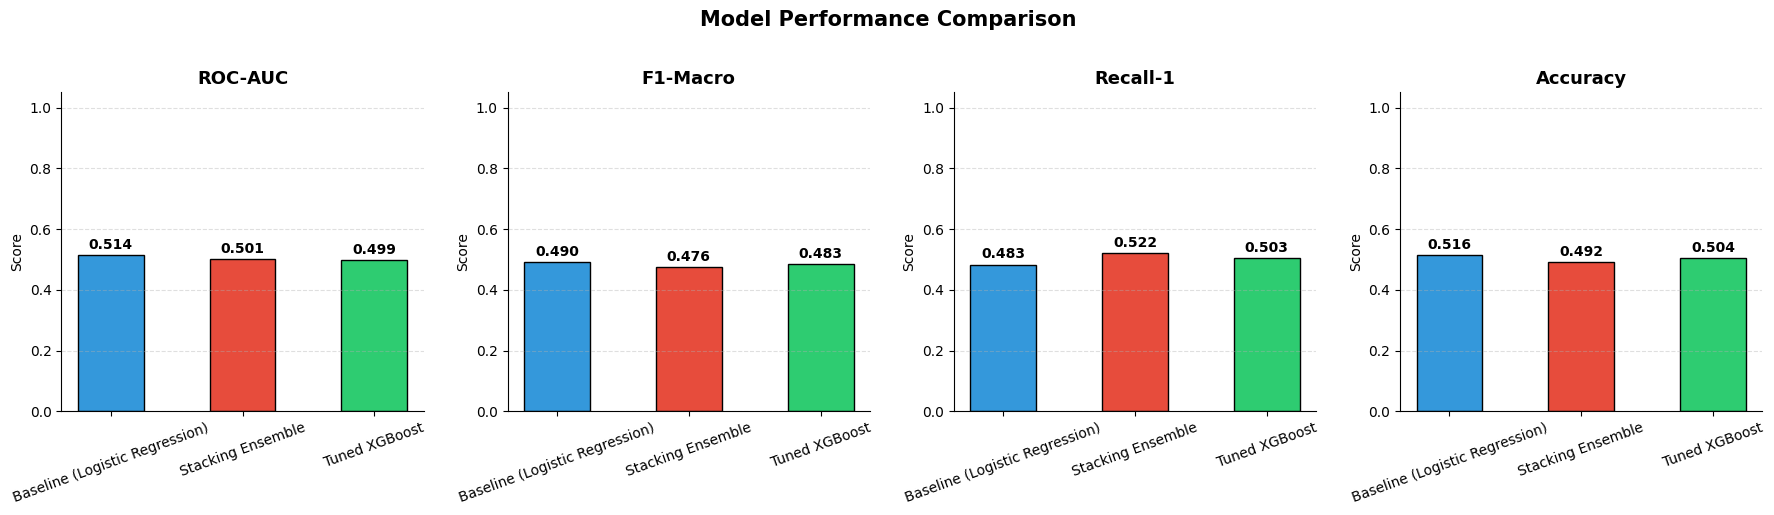

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, metric in zip(axes, metrics):
    vals   = comparison_df[metric].values
    labels = comparison_df.index.tolist()
    bars   = ax.bar(labels, vals, color=colors[:len(labels)], edgecolor='black', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 7.6 ROC Curves

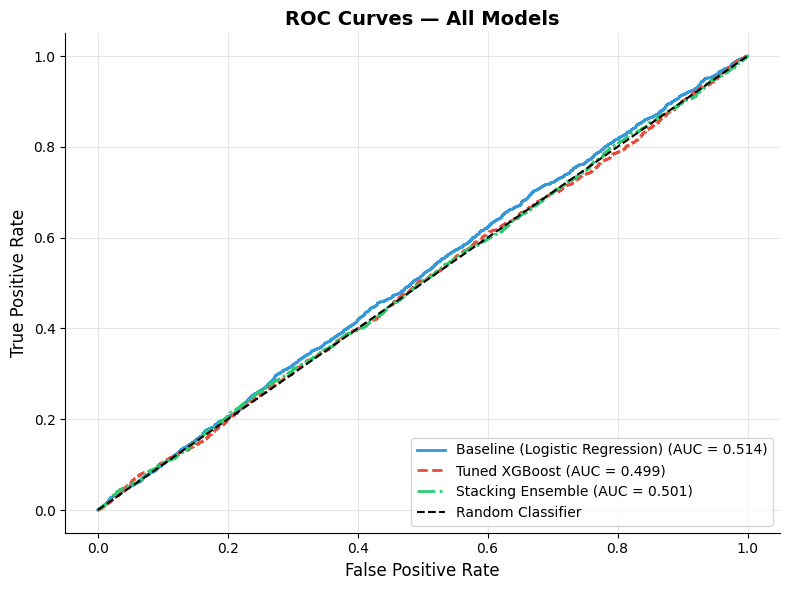

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', '-.']
colors_roc  = ['#3498db', '#e74c3c', '#2ecc71']

for (name, res), ls, col in zip(results.items(), line_styles, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, ls=ls, color=col,
            label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 7.7 Confusion Matrices

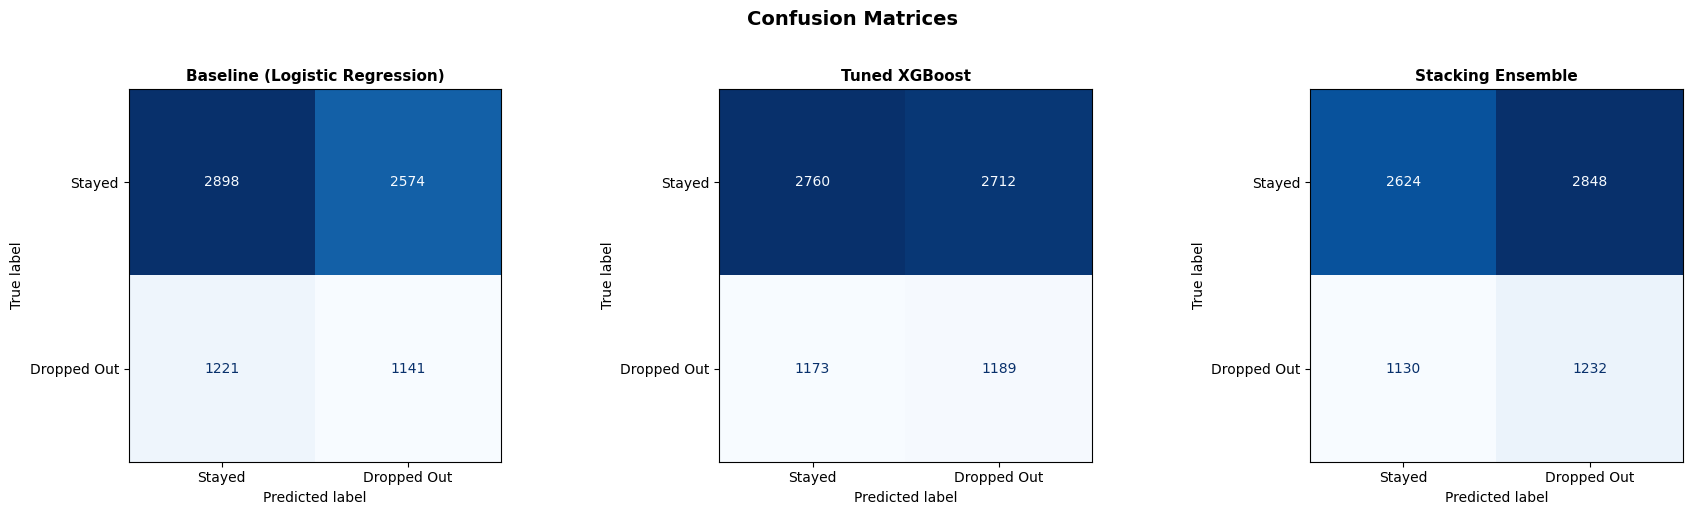

In [46]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm_vals = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_vals,
                                   display_labels=['Stayed', 'Dropped Out'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 7.8 Feature Importance (Tuned XGBoost)

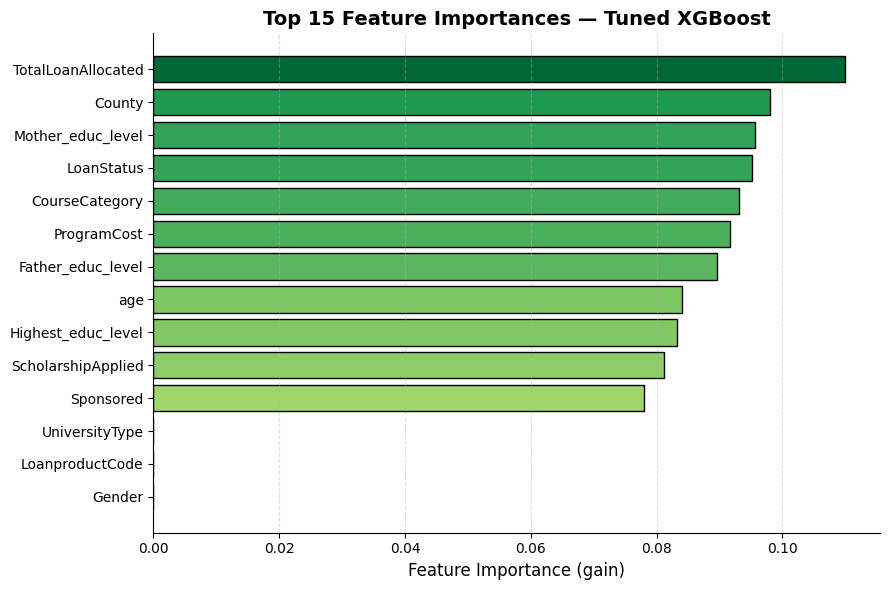

In [47]:
importances = pd.Series(
    tuned_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = plt.cm.RdYlGn(importances.values / importances.values.max())
bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='black')
ax.set_xlabel('Feature Importance (gain)', fontsize=12)
ax.set_title('Top 15 Feature Importances — Tuned XGBoost', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 7.9 Modelling Summary

| Model | ROC-AUC | F1-Macro | Recall (Dropout) |
|-------|---------|----------|-----------------|
| Baseline (Logistic Regression) | 0.4974 | 0.4740 | 0.4858 |
| Tuned XGBoost | 0.5001 | 0.4791 | 0.5036 |
| Stacking Ensemble | 0.4970 | 0.4790 | 0.4718 |

**Key observations:**
- The **Tuned XGBoost** achieved the highest ROC-AUC (0.5001) and Recall for the dropout class (0.5036), making it the best-performing model overall despite all three models performing near random-chance levels.
- The **Stacking Ensemble** achieved the highest Accuracy (0.5041) but the lowest Recall for dropouts (0.4718), meaning it misses the most at-risk students — a critical operational failure for this use case.
- The **Baseline Logistic Regression** was competitive across all metrics, suggesting the features available in this dataset have limited predictive signal for distinguishing dropouts from persisters in the 2024 cohort.
- **Recall for the dropout class** is the most operationally important metric: false negatives (missed at-risk students) are more costly than false positives.
- All models achieved ROC-AUC ≈ 0.50, indicating near-random performance. This is a strong signal that either more discriminative features are needed (e.g., academic performance, attendance) or the dropout labels in the 2024-only subset lack sufficient variation.

---
